In [63]:
import sys
import os 

import cartopy.geodesic as gd
import networkx as nx
import numpy as np
import pypsa
from shapely.geometry import Point
from scipy.sparse import spdiags

sys.path.append('./')
from power_system_split import utils, cascade_sim
from matplotlib import pyplot as plt

from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
import cartopy.crs as ccrs

from tqdm import tqdm
import pandas as pd

# You have to `pip install memory_profiler`
%load_ext line_profiler

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


# Pre-outage data

In [4]:
co2l_list = [0.1] #np.arange(0.0,0.99,0.05)


inertia_results = {'lopf':{'ts':[],
                           'nodal':[]},
                   'sclopf':{'ts':[],
                             'nodal':[]}}

for network_path, prefix, name in zip(['./data/European_networks_sclopf/','./data/European_networks_lopf/'],
                                      ['sclopf-',''],
                                      ['sclopf','lopf']):
    
    # Setup paths 
    path_to_pypsa_network   = network_path

    # Setup parameters for network
    criterion = 'nodes' 
    snet_index = 0 # only AC grid of CE
    

    # Load network
    network = pypsa.Network()
    network.import_from_netcdf(path_to_pypsa_network+prefix+'elec_s_800_ec_lv1.0_Co2L0.1-3H.nc') 
    outage_lines = network.lines[network.lines.index.str[-6:]=='outage'].index# needed to remoce SCLOPF's "outage lines"
    network.mremove('Line', outage_lines)# needed to remoce SCLOPF's "outage lines"
    G = utils.build_networkx_graph(network,snet_index = snet_index)
    pos = nx.get_node_attributes(G,'pos')


    ### Calculate (total) inertia time series #####

    print('\nCalculate total inertia time series ...')
    inertia_time_series = np.zeros((len(co2l_list),2920))

    for i, co2l in enumerate(co2l_list):
        print('Co2 level %.2f' % co2l)
        level = np.round(co2l,2)
        network = pypsa.Network()
        network.import_from_netcdf(path_to_pypsa_network+prefix+f'elec_s_800_ec_lv1.0_Co2L{level}-3H.nc')  
        outage_lines = network.lines[network.lines.index.str[-6:]=='outage'].index # needed to remoce SCLOPF's "outage lines"
        network.mremove('Line', outage_lines) # needed to remoce SCLOPF's "outage lines"
        inertia_time_series[i] = utils.calc_system_inertia_over_time(network,snet_index = 0)

    inertia_results[name]['ts'] = inertia_time_series
    
    
    #### Calculate inertia generation time series per node for two Co2 levels ####

    print('\nCalculate inertia generation time series per node...')
    target_levels = [0.1]
    inertia_generation = np.zeros((len(target_levels),2,len(G.nodes())))

    for j,level in enumerate(target_levels):
        
        # Load PyPSA network for co2 level
        network = pypsa.Network()
        network.import_from_netcdf(path_to_pypsa_network+prefix+f'elec_s_800_ec_lv1.0_Co2L{np.round(level,2)}-3H.nc') 
        outage_lines = network.lines[network.lines.index.str[-6:]=='outage'].index # needed to remoce SCLOPF's "outage lines"
        network.mremove('Line', outage_lines)# needed to remoce SCLOPF's "outage lines"
        
        # Select timestamps with min and max total inertia     
        level_index = np.where(np.round(co2l_list,2) == level)[0][0]
        sorted_inertia_time_index = np.argsort(inertia_time_series[level_index])
        t_largest_inertia = network.snapshots[sorted_inertia_time_index[-1]]
        t_smallest_inertia = network.snapshots[sorted_inertia_time_index[0]]
        timestamps = [t_smallest_inertia, t_largest_inertia]
        
        # Calculate inertia generation per node
        load_shedding_indices = network.generators[network.generators.carrier.isin(['load'])].index
        for i,timestamp in enumerate(timestamps):
            current_generation = network.generators_t.p.loc[timestamp].copy()
            current_generation[load_shedding_indices] /= 1e3
            current_storage    = network.storage_units_t.p.loc[timestamp]
            for nodecount,node in enumerate(G.nodes()):
                subgraph = nx.Graph()
                subgraph.add_node(node)
                inertia_generation[j,i,nodecount] = utils.get_inertia_gen_subgraph(subgraph,
                                                                                network.generators,
                                                                                current_generation,
                                                                                network.storage_units,
                                                                                current_storage,
                                                                                use_pnom = True)
    inertia_results[name]['nodal'] = inertia_generation

     


/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network sclopf-elec_s_800_ec_lv1.0_Co2L0.1-3H.nc has buses, carriers, generators, lines, links, loads, storage_units



Calculate total inertia time series ...
Co2 level 0.10


/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network sclopf-elec_s_800_ec_lv1.0_Co2L0.1-3H.nc has buses, carriers, generators, lines, links, loads, storage_units



Calculate inertia generation time series per node...


/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network sclopf-elec_s_800_ec_lv1.0_Co2L0.1-3H.nc has buses, carriers, generators, lines, links, loads, storage_units
/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical o


Calculate total inertia time series ...
Co2 level 0.10


/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.1-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units



Calculate inertia generation time series per node...


/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.1-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


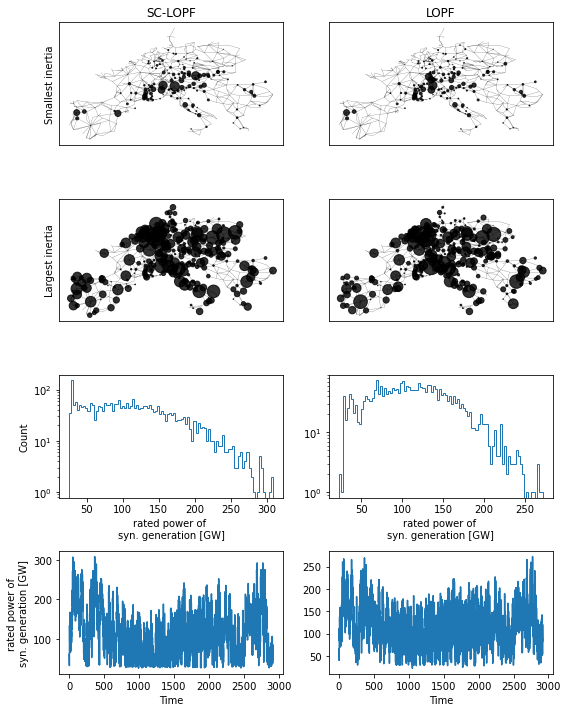

In [6]:
fig, axs = plt.subplots(4,2, figsize=(8,10))


axs[3,0].plot(inertia_results['sclopf']['ts'][0]/1000)

axs[2,0].hist(inertia_results['sclopf']['ts'][0]/1000,
            bins=100,
            histtype='step'),
axs[2,0].set_yscale('log')


axs[3,1].plot(inertia_results['lopf']['ts'][0]/1000)

axs[2,1].hist(inertia_results['lopf']['ts'][0]/1000,
            bins=100,
            histtype='step'),
axs[2,1].set_yscale('log')

for i in [0,1]:
    nx.draw_networkx_nodes(G,
                            pos,
                            ax=axs[i][0],
                            node_size=inertia_results['sclopf']['nodal'][0][i]/28,
                            alpha=0.8,
                            node_color='black')
    nx.draw_networkx_edges(G,
                            pos,
                            ax=axs[i][0],
                            alpha=0.8,
                            width=0.2)

    nx.draw_networkx_nodes(G,
                            pos,
                            ax=axs[i][1],
                            node_size=inertia_results['lopf']['nodal'][0][i]/28,
                            alpha=0.8,
                            node_color='black')
    nx.draw_networkx_edges(G,
                            pos,
                            ax=axs[i][1],
                            alpha=0.8,
                            width=0.2)

axs[0,0].set_ylabel('Smallest inertia')
axs[1,0].set_ylabel('Largest inertia')
axs[2,0].set_ylabel('Count')
axs[3,0].set_ylabel('rated power of \nsyn. generation [GW]')

axs[2,0].set_xlabel('rated power of \nsyn. generation [GW]')
axs[2,1].set_xlabel('rated power of \nsyn. generation [GW]')

axs[3,0].set_xlabel('Time')
axs[3,1].set_xlabel('Time')


axs[0,0].set_title('SC-LOPF')
axs[0,1].set_title('LOPF')

plt.tight_layout()
#plt.savefig('./fig4_lopf_sclopf_comparison.pdf')


In [7]:
dipole_results = {'lopf':{'dipole_vector':[],
                           'mean_pos':[],
                           'norm':[]},
                   'sclopf':{'dipole_vector':[],
                           'mean_pos':[],
                           'norm':[]}}

for network_path, prefix, name in zip(['./data/European_networks_sclopf/','./data/European_networks_lopf/'],
                                      ['sclopf-',''],
                                      ['sclopf','lopf']):

    # Setup paths 
    path_to_pypsa_network   = network_path
    
    #### Calculate dipole vectors ####

    print('\nCalculate dipole vectors...')
    dipole_vector = np.zeros((len(co2l_list),2,len(network.snapshots)))

    mean_consumption_vector = np.zeros((len(co2l_list),len(G.nodes())))
    graph_net_mismatch = np.zeros((len(co2l_list),len(network.snapshots)))

    for i,co2l in enumerate(co2l_list):
        
        print('Co2 level %.2f' % co2l)
        
        network = pypsa.Network()
        level = np.round(co2l,2)
        network.import_from_netcdf(path_to_pypsa_network+prefix+f'elec_s_800_ec_lv1.0_Co2L{level}-3H.nc')  
        outage_lines = network.lines[network.lines.index.str[-6:]=='outage'].index # needed to remoce SCLOPF's "outage lines"
        network.mremove('Line', outage_lines)# needed to remoce SCLOPF's "outage lines"
        
        ### NOTE: Here, the mean position is subtracted from the coordinates
        position_vector = np.array([pos[n] for n in G.nodes()])
        position_vector[:,1] -= np.mean(position_vector[:,1])
        position_vector[:,0] -= np.mean(position_vector[:,0])    
        
        nodal_balance = (network.generators_t.p.T.groupby(network.generators["bus"]).sum()-\
                        network.loads_t.p.T.groupby(network.loads["bus"]).sum()+\
                        network.storage_units_t.p.T.groupby(network.storage_units["bus"]).sum()).copy()
        
        ## add hvdc link subtraction/addition
        nodal_balance = nodal_balance.add(-network.links_t.p0.T.groupby(network.links["bus0"]).sum(), fill_value=0)
        nodal_balance = nodal_balance.add(-network.links_t.p1.T.groupby(network.links["bus1"]).sum(), fill_value=0)
        
        nodal_balance = -nodal_balance
        
        for nodecount,node in enumerate(G.nodes()):
            mean_consumption_vector[i,nodecount] = nodal_balance.mean(axis = 1).loc[node]
            graph_net_mismatch[i] += nodal_balance.loc[node]
            dipole_vector[i] += np.outer(position_vector[nodecount],nodal_balance.loc[node].to_numpy())
            

    #### Calculate spatial power inhomogeneity ####


    print('\nCalculate spatial power inhomogeneity...')
    vec_norm = np.zeros((len(co2l_list),len(network.snapshots)))
    positions = np.array([pos[n] for n in G.nodes()])
    mean_pos = np.array([np.mean(positions[:,0]),np.mean(positions[:,1])])
    scale_factor = 1e6

    k = gd.Geodesic() 

    for i,co2l in enumerate(co2l_list):
        print('Co2 level %.2f' % co2l)

        for j in range(len(network.snapshots)):
            shapely_pos = Point(dipole_vector[i,:,j]/scale_factor+mean_pos)
            distance = k.inverse(shapely_pos, Point(mean_pos))[0,0]/1000
            vec_norm[i,j] = distance


    dipole_results[name]['mean_pos'] = mean_pos
    dipole_results[name]['vec_norm'] = vec_norm
    dipole_results[name]['dipole_vector'] = dipole_vector


Calculate dipole vectors...
Co2 level 0.10


/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network sclopf-elec_s_800_ec_lv1.0_Co2L0.1-3H.nc has buses, carriers, generators, lines, links, loads, storage_units



Calculate spatial power inhomogeneity...
Co2 level 0.10

Calculate dipole vectors...
Co2 level 0.10


/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.1-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units



Calculate spatial power inhomogeneity...
Co2 level 0.10


/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.1-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


Text(0, 0.5, 'Count')

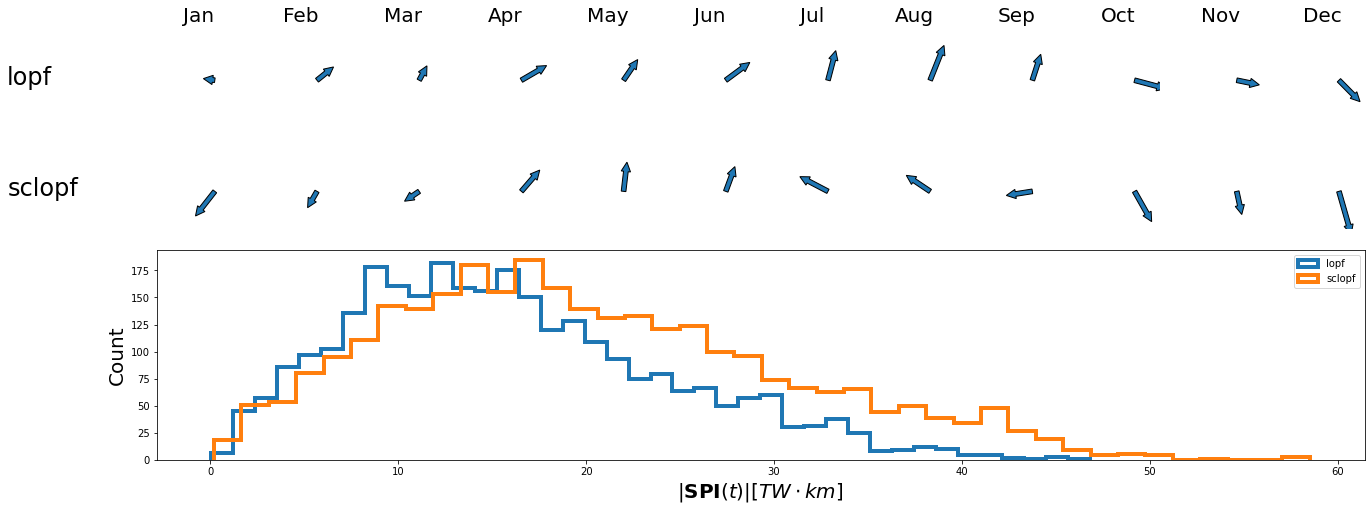

In [8]:
f = plt.figure(figsize=(19, 7), constrained_layout=True)

gs = GridSpec(3,12, figure=f, hspace=0, height_ratios=[1,1,2]) # outer grid
axs1 = [f.add_subplot(gs[0,i], projection=ccrs.PlateCarree()) for i in range(12)]
axs2 = [f.add_subplot(gs[1,i], projection=ccrs.PlateCarree()) for i in range(12)]
axs3 = f.add_subplot(gs[2, :])

network_old = pypsa.Network()
network_old.import_from_netcdf('./data/European_networks_lopf/elec_s_800_ec_lv1.0_Co2L0.1-3H.nc') 
outage_lines = network.lines[network.lines.index.str[-6:]=='outage'].index # needed to remoce SCLOPF's "outage lines"
network.mremove('Line', outage_lines)# needed to remoce SCLOPF's "outage lines"


for ax, name in zip([axs1, axs2],['lopf', 'sclopf']):

    old_ind = 0
    co2ls = np.array([0.1])
    scale_factor = 1e4


    for j in range(12):

        new_ind = old_ind + \
            len(network.snapshots[network.snapshots.month == int(j+1)])

        current_vec = np.mean(dipole_results[name]['dipole_vector'][:, :, old_ind:new_ind], axis=2)
        
        current_level = 0.1
        ind = np.where(np.round(co2ls, 2) == current_level)[0][0]

        ax[j].arrow(dipole_results[name]['mean_pos'][0],
                                        dipole_results[name]['mean_pos'][1],
                                        current_vec[ind, 0]/scale_factor,
                                        current_vec[ind, 1]/scale_factor,
                                        head_width=4,
                                        width=2.0,
                                        head_length=4,
                                        #alpha  = .8,
                                        )
        
        if name=='lopf':
            ax[j].set_title(network_old.snapshots[network_old.snapshots.month == j+1][0].month_name()[:3],
                                        fontsize=20, pad=20)
        ax[j].axis('off')
        ax[j].set_ylim([30.707498915424157, 63.29928495567561])
        ax[j].set_xlim([-160000/scale_factor, 200000/scale_factor])
        old_ind = new_ind
        
        
    ax[0].text(-80, 45, name, fontsize=24)

    
    axs3.hist(dipole_results[name]['vec_norm'][0], histtype='step', bins=40, label=name, lw=4)
axs3.legend()
axs3.set_xlabel(r'$|\mathbf{SPI}(t)| [TW\cdot km]$', fontsize=20)
axs3.set_ylabel('Count', fontsize=20)

#plt.savefig('./fig3_lopf_sclopf_comparison.pdf')



# Run cascade

### prepare cascade simulation

In [64]:
# Setup paths to solved PyPSA networks and results of this script
path_to_pypsa_network   = './data/European_networks_sclopf/'
save_path =  './results/cascade_results/sclopf/'

# Load co2 level
co2l = 0.5 # float(sys.argv[1])

# Load PyPSA network
network = pypsa.Network()
network.import_from_netcdf(path_to_pypsa_network+f'sclopf-elec_s_800_ec_lv1.0_Co2L{co2l}-3H.nc')


# The following line is needed to remove the outage lines used for SCLOPF. When not removed, multiple edges 
# are added to the network graph
outage_lines = network.lines[network.lines.index.str[-6:]=='outage'].index
network.mremove('Line', outage_lines)
network.determine_network_topology()



######
#TODO: remove this line if the networks contain timestamp snapshots
network.snapshots = pd.date_range(start='2013', freq='3H', periods=len(network.snapshots))

network.snapshot_weightings.index = pd.date_range(start='2013', freq='3H', periods=len(network.snapshots))

for component in network.all_components:
    pnl = network.pnl(component)
    attrs = network.components[component]["attrs"]

    for k,default in attrs.default[attrs.varying].iteritems():
        pnl[k].index = pd.date_range(start='2013', freq='3H', periods=len(network.snapshots))
######


# Select a particular subnetwork for calculations (if the pypsa network has different ones).
# Otherwise you can choose None or -1.
# For our data set, "0" indicates the Continental European AC grid. 
snet_index = 0

# Build graph for subnetwork
G = utils.build_networkx_graph(network, snet_index= snet_index)


# Get line index 
# Line index is a unique number to identify the given edge.
# It is directly extracted from pypsa
indices = nx.get_edge_attributes(G, 'line_index')

# Extract time steps
snapshot = network.snapshots[1000]

# Build incidence matrix and susceptance matrix
I_m = utils.construct_incidencematrix_from_orientation(G,return_np_array = False) 
B_d = spdiags(np.array([attribs['weight'] for u,v, attribs in G.edges(data=True)]),
              0,G.number_of_edges(),G.number_of_edges()).asformat('csc')

# Get array of num_parallels and of line limits
num_parallel_list = np.array([attribs['num_parallel'] for u,v, attribs in G.edges(data=True)])
line_limit_list = np.array([attribs['s_nom'] for u,v, attribs in G.edges(data=True)])

# Calculate possible double line failure (using non-bridges)
bridges = list(nx.bridges(nx.Graph(G)))
link_indices = dict(zip(G.edges(), range(G.number_of_edges())))
bridges_indices = [link_indices[link_name] for link_name in bridges]
possible_failures = cascade_sim.calc_possible_double_line_failures(num_parallel_list,
                                                                   bridges_indices)

initial_loading = {e: np.sum([network.lines_t.p0.loc[snapshot].loc[index] for index in index_list]) for
                    e, index_list in indices.items()}
P_0 = utils.get_effective_injections(G, initial_loading)

l_copy = initial_loading.copy()
for key in l_copy.keys():
    initial_loading[key[::-1]] = initial_loading[key]


/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network sclopf-elec_s_800_ec_lv1.0_Co2L0.5-3H.nc has buses, carriers, generators, lines, links, loads, storage_units


In [66]:
np.show_config()

blas_mkl_info:
    libraries = ['mkl_rt', 'pthread']
    library_dirs = ['/home/jkruse/.conda/envs/system_split/lib']
    define_macros = [('SCIPY_MKL_H', None), ('HAVE_CBLAS', None)]
    include_dirs = ['/home/jkruse/.conda/envs/system_split/include']
blas_opt_info:
    libraries = ['mkl_rt', 'pthread']
    library_dirs = ['/home/jkruse/.conda/envs/system_split/lib']
    define_macros = [('SCIPY_MKL_H', None), ('HAVE_CBLAS', None)]
    include_dirs = ['/home/jkruse/.conda/envs/system_split/include']
lapack_mkl_info:
    libraries = ['mkl_rt', 'pthread']
    library_dirs = ['/home/jkruse/.conda/envs/system_split/lib']
    define_macros = [('SCIPY_MKL_H', None), ('HAVE_CBLAS', None)]
    include_dirs = ['/home/jkruse/.conda/envs/system_split/include']
lapack_opt_info:
    libraries = ['mkl_rt', 'pthread']
    library_dirs = ['/home/jkruse/.conda/envs/system_split/lib']
    define_macros = [('SCIPY_MKL_H', None), ('HAVE_CBLAS', None)]
    include_dirs = ['/home/jkruse/.conda/envs/system_

### profile cascade algorithm

In [5]:
def profiling_function(I_m, B_d, P_0, line_limit_list,num_parallel_list,possible_failures):
    
    for i, initial_failure in enumerate(possible_failures):
        failing_links, system_split = cascade_sim.simulate_cascade(I_m, B_d, P_0, line_limit_list,
                                                                num_parallel_list, initial_failure)
            
%lprun -f cascade_sim.simulate_cascade profiling_function(I_m, B_d, P_0, line_limit_list,num_parallel_list,possible_failures[:5000])

Timer unit: 1e-06 s

Total time: 19.3142 s
File: /media/jkruse/Projects/system_splits/power-system-split/power_system_split/cascade_sim.py
Function: simulate_cascade at line 98

Line #      Hits         Time  Per Hit   % Time  Line Contents
    98                                           def simulate_cascade(II_in, B_d_in,
    99                                                                P0, line_limits_in, num_parallel_in, failure_links):
   100                                               """Simulate a cascade with the given inital failure links:
   101                                           
   102                                               Args:
   103                                                   II_in (sparse matrix): Incidence matrix
   104                                                   B_d_in (_type_): Diagonal matrix with susecptance on diagonal.
   105                                                   P0 (1d numpy array): power injections/extractions 
   10

In [117]:
t_sim = 12 # in seconds
n_init_failures = 5000 # number of initial failures simulated
t_total = (network.snapshots.shape[0]*t_sim*len(possible_failures)/n_init_failures)/3600/24

print('Estimated time for simulating one Co2 level:',
      round(t_total),
      ' d')

Estimated time for simulating one Co2 level: 37  d


### Plot failing links for one example initial failure


In [55]:
# Simulate cascade for every tuple of trigger links
# Print if a split happened

split_results = {}
i=0

selected_possible_failures = np.array(possible_failures)[np.random.randint(0,len(possible_failures),100000)]

for init_failure in tqdm(selected_possible_failures):

    initial_failure = list(init_failure)
    failing_links, system_split = cascade_sim.simulate_cascade(I_m, B_d, P_0, line_limit_list,
                                                                num_parallel_list, initial_failure)
    if system_split:
        split_results[i] =failing_links
    i+=1

 73%|███████▎  | 72676/100000 [03:02<01:08, 397.88it/s]


KeyboardInterrupt: 

In [56]:
# Find keys with large system splits
for key, item in split_results.items():
    if len(item)>4:
        print(key)

529
11026
19183
20993
32614
33134
36485
39846
45566
64623
64695


failing_links [('LU0 0', 'DE0 118'), ('NL0 26', 'DE0 79'), ('BE0 2', 'LU0 0'), ('LU0 0', 'DE0 118'), ('NL0 26', 'DE0 79')] 

('LU0 0', 'DE0 118') 0.005540166204986097
('NL0 26', 'DE0 79') 1.0
[] [('LU0 0', 'DE0 118'), ('NL0 26', 'DE0 79')]


(<matplotlib.collections.PatchCollection at 0x7fc8bd7250d0>,
 <matplotlib.collections.LineCollection at 0x7fc8cbcf8790>)

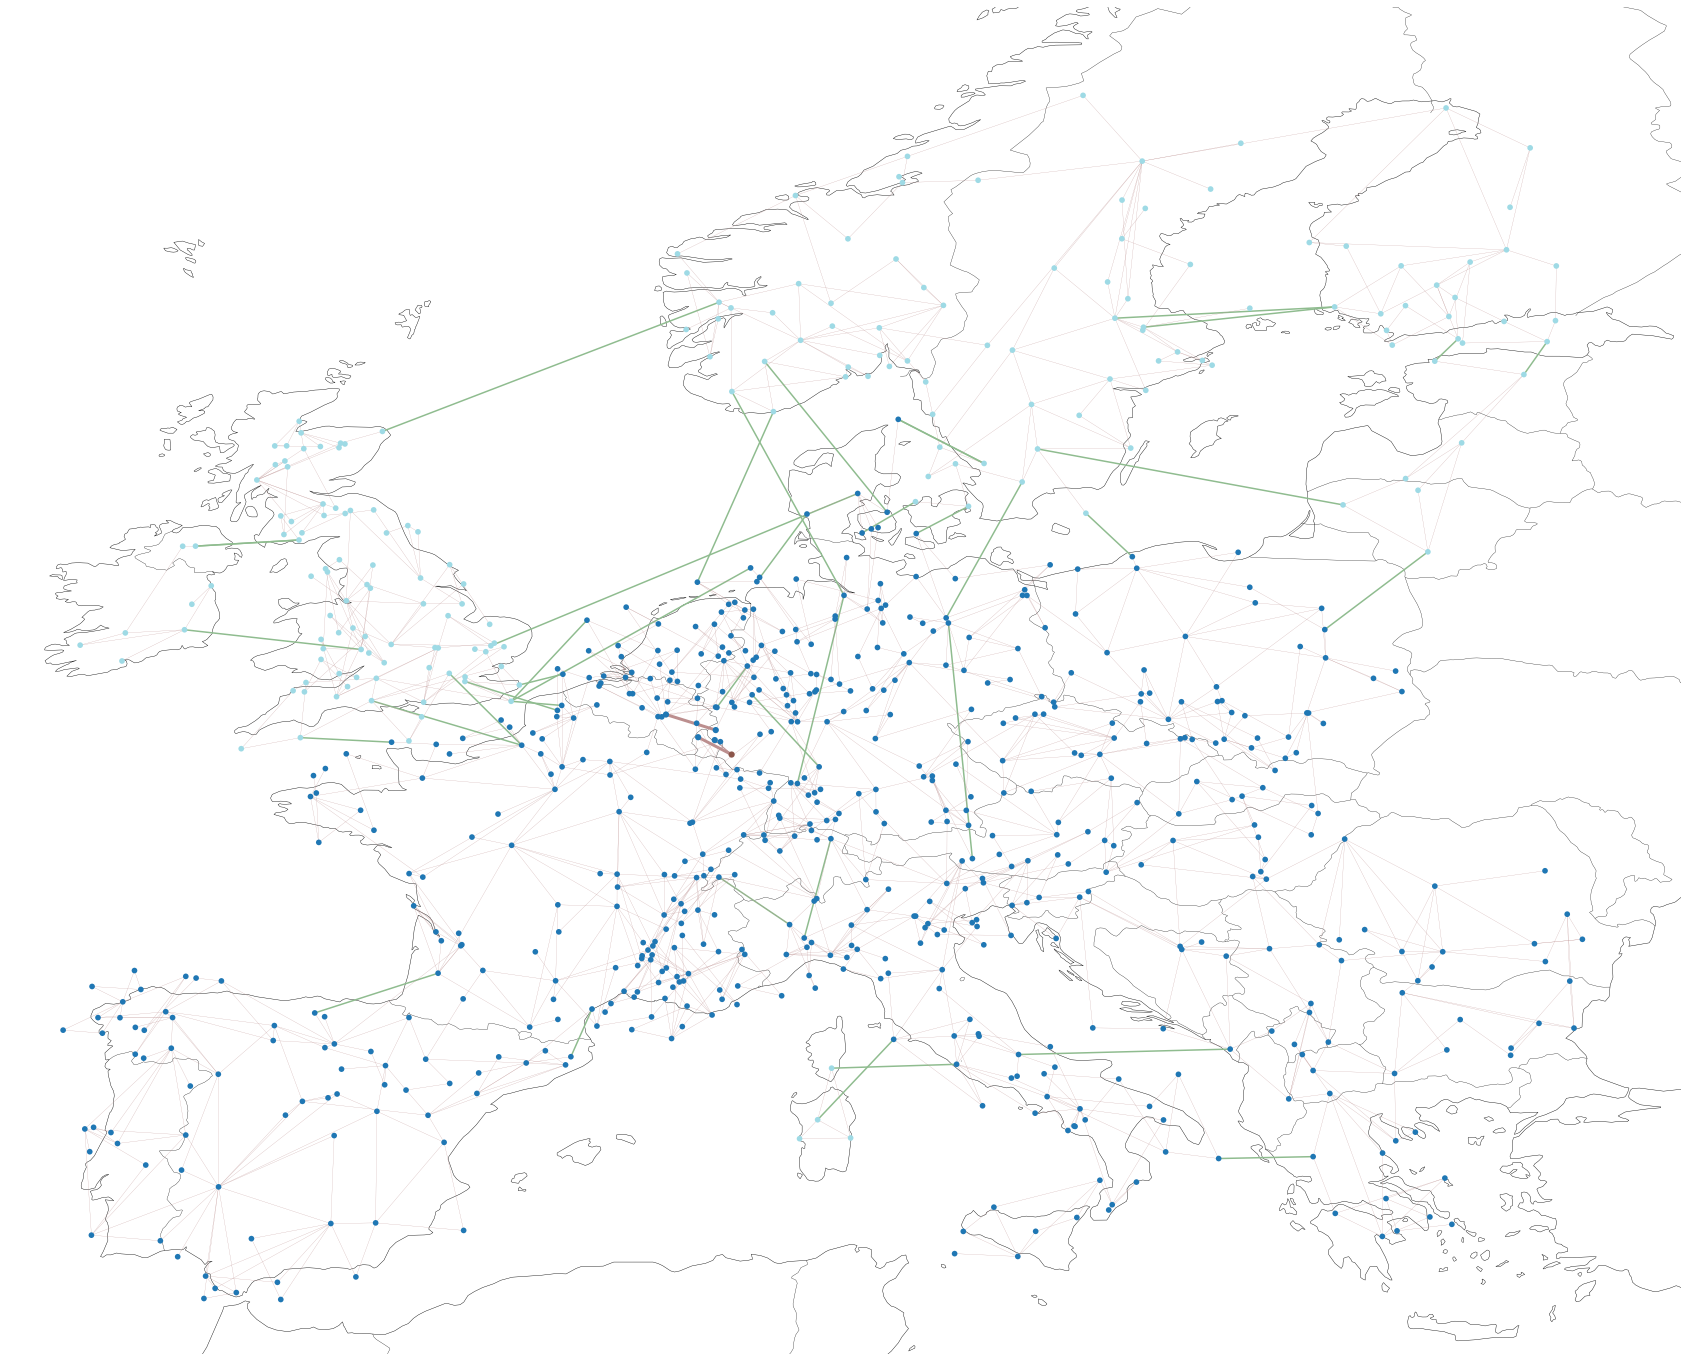

In [62]:
# Plot map of system split and failing lines for one key
idx_key = 529
#idx = 10
failing_links = split_results[idx_key] 
#failing_links = split_results[list(split_results.keys())[idx]]

link_names = dict(zip(range(G.number_of_edges()), G.edges()))
failing_links = [link_names[link] for link in failing_links]
print('failing_links', failing_links, '\n')

plt.figure(figsize=(30,30))
lws = np.ones(network.lines.shape[0])*0.2
bs = np.ones(network.buses.shape[0])*0.005
bc = np.ones(network.buses.shape[0])

for e in failing_links[2:]:
    lws[((network.lines.bus0==e[0])&(network.lines.bus1==e[1]))|((network.lines.bus0==e[1])&(network.lines.bus1==e[0]))]=1
    bs[network.buses.index==e[0]] =0.006
    bs[network.buses.index==e[1]] =0.006
    
for e in failing_links[:2]:
    lws[((network.lines.bus0==e[0])&(network.lines.bus1==e[1]))|((network.lines.bus0==e[1])&(network.lines.bus1==e[0]))]=3
    bs[network.buses.index==e[0]] =0.006
    bs[network.buses.index==e[1]] =0.006
    
G_2 = G.copy()     
init_failures = failing_links[:2]
removed_init_links = []
for link in init_failures:
    n_par_new = cascade_sim.calc_num_parallel_after_failure(G_2.get_edge_data(link[0], link[1])['num_parallel'])
    G_2.get_edge_data(link[0], link[1])['num_parallel'] = n_par_new
    print(link, n_par_new)
    if n_par_new==0:
        removed_init_links += [link]
G_2.remove_edges_from(failing_links[2:]+removed_init_links)
if removed_init_links!=failing_links[:2]:
    print(removed_init_links, failing_links[:2])
    
    
subgraphs =  list((G_2.subgraph(c).copy() for c in nx.connected_components(G_2)))

for i in range(network.buses.shape[0]):
    bus = network.buses.index[i]
    for j, subgraph in enumerate(subgraphs):
        if bus in subgraph:
            bc[i]=(np.arange(len(subgraphs))/len(subgraphs))[j]

network.plot(line_widths=lws, bus_sizes=bs, jitter=1, bus_colors=bc, bus_cmap='tab20')